##### ARTI 560 - Computer Vision

## Visual Representations with DINOv2 - Exercise

### Exercise 1: Unsupervised Clustering

In this exercise, you will use the `KMeans` algorithm from sklearn to group 20 images from the Oxford Pet dataset into 2 clusters (Cats vs. Dogs) based purely on their CLS tokens.

Instructions:

1.  Extract the 384-dimensional [CLS] tokens from 20 images of the Oxford-IIIT Pet dataset. Ensure your selection includes a mix of both cats and dogs.

2. Apply K-Means Clustering ($n=2$) to group the vectors based on mathematical similarity rather than provided labels.

3. Compare the predicted clusters against ground-truth labels.

In [34]:
# !pip install torch torchvision transformers pillow scikit-learn pandas matplotlib seaborn

import os
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from PIL import Image
import matplotlib.pyplot as plt

from transformers import AutoImageProcessor, AutoModel, AutoImageProcessor, AutoModelForImageClassification
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [35]:
import zipfile
from pathlib import Path

zip_path = "/content/pets.zip"
extract_path = "/content/pets"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted successfully.")

Extracted successfully.


In [36]:
from pathlib import Path
import pandas as pd

IMAGE_FOLDER = r"/content/pets"

image_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

cat_paths = sorted([
    p for p in Path(IMAGE_FOLDER).rglob("*")
    if p.suffix.lower() in image_extensions and p.parent.name.lower() == "cats"
])

dog_paths = sorted([
    p for p in Path(IMAGE_FOLDER).rglob("*")
    if p.suffix.lower() in image_extensions and p.parent.name.lower() == "dogs"
])

print("Cats found:", len(cat_paths))
print("Dogs found:", len(dog_paths))

image_paths = cat_paths[:10] + dog_paths[:10]

print("Selected images:")
for p in image_paths:
    print(p)

def infer_label(path):
    folder_name = path.parent.name.lower()

    if folder_name == "cats":
        return "cat"
    elif folder_name == "dogs":
        return "dog"
    else:
        return "unknown"

true_labels = [infer_label(p) for p in image_paths]

print("Ground truth labels:", pd.Series(true_labels).value_counts().to_dict())

Cats found: 20
Dogs found: 20
Selected images:
/content/pets/cats/Bengal_24.jpg
/content/pets/cats/Bengal_26.jpg
/content/pets/cats/Bengal_27.jpg
/content/pets/cats/Bengal_28.jpg
/content/pets/cats/Bengal_29.jpg
/content/pets/cats/Bengal_41.jpg
/content/pets/cats/Bombay_139.jpg
/content/pets/cats/Bombay_14.jpg
/content/pets/cats/Bombay_144.jpg
/content/pets/cats/Bombay_184.jpg
/content/pets/dogs/image (1).jpg
/content/pets/dogs/image (10).jpg
/content/pets/dogs/image (11).jpg
/content/pets/dogs/image (12).jpg
/content/pets/dogs/image (13).jpg
/content/pets/dogs/image (14).jpg
/content/pets/dogs/image (15).jpg
/content/pets/dogs/image (16).jpg
/content/pets/dogs/image (17).jpg
/content/pets/dogs/image (18).jpg
Ground truth labels: {'cat': 10, 'dog': 10}


In [37]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

feature_model_id = "facebook/dinov2-small"
processor = AutoImageProcessor.from_pretrained(feature_model_id)
model = AutoModel.from_pretrained(feature_model_id).to(device)
model.eval()

Using device: cpu


Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]

Dinov2Model(
  (embeddings): Dinov2Embeddings(
    (patch_embeddings): Dinov2PatchEmbeddings(
      (projection): Conv2d(3, 384, kernel_size=(14, 14), stride=(14, 14))
    )
    (dropout): Dropout(p=0.0, inplace=False)
  )
  (encoder): Dinov2Encoder(
    (layer): ModuleList(
      (0-11): 12 x Dinov2Layer(
        (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
        (attention): Dinov2Attention(
          (attention): Dinov2SelfAttention(
            (query): Linear(in_features=384, out_features=384, bias=True)
            (key): Linear(in_features=384, out_features=384, bias=True)
            (value): Linear(in_features=384, out_features=384, bias=True)
          )
          (output): Dinov2SelfOutput(
            (dense): Linear(in_features=384, out_features=384, bias=True)
            (dropout): Dropout(p=0.0, inplace=False)
          )
        )
        (layer_scale1): Dinov2LayerScale()
        (drop_path): Identity()
        (norm2): LayerNorm((384,), eps=1e-06,

In [38]:
features = []
valid_paths = []
valid_labels = []

with torch.no_grad():
    for path, label in zip(image_paths, true_labels):
        image = Image.open(path).convert("RGB")
        inputs = processor(images=image, return_tensors="pt").to(device)
        outputs = model(**inputs)
        cls_token = outputs.last_hidden_state[:, 0, :]
        features.append(cls_token.squeeze().cpu().numpy())
        valid_paths.append(path)
        valid_labels.append(label)

X = np.vstack(features)
print("Feature matrix shape:", X.shape)

Feature matrix shape: (20, 384)


In [39]:
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X)

results_df = pd.DataFrame({
    "image": [p.name for p in image_paths],
    "true_label": true_labels,
    "cluster": clusters
})

results_df

,image,true_label,cluster
0,Bengal_24.jpg,cat,0
1,Bengal_26.jpg,cat,0
2,Bengal_27.jpg,cat,0
3,Bengal_28.jpg,cat,0
4,Bengal_29.jpg,cat,0
5,Bengal_41.jpg,cat,0
6,Bombay_139.jpg,cat,1
7,Bombay_14.jpg,cat,1
8,Bombay_144.jpg,cat,1
9,Bombay_184.jpg,cat,1


In [40]:
cluster_to_label = {}

for cluster in sorted(results_df["cluster"].unique()):
    majority_label = results_df[results_df["cluster"] == cluster]["true_label"].mode()[0]
    cluster_to_label[cluster] = majority_label

results_df["predicted_label"] = results_df["cluster"].map(cluster_to_label)

known_results = results_df[results_df["true_label"] != "unknown"].copy()

print("\nCluster-to-label mapping:", cluster_to_label)
print("\nFinal results:")
print(results_df)

if len(known_results) > 0:
    print("\nAccuracy:", accuracy_score(
        known_results["true_label"],
        known_results["predicted_label"]
    ))

    print("\nConfusion matrix:")
    print(confusion_matrix(
        known_results["true_label"],
        known_results["predicted_label"],
        labels=["cat", "dog"]
    ))

    print("\nClassification report:")
    print(classification_report(
        known_results["true_label"],
        known_results["predicted_label"]
    ))


Cluster-to-label mapping: {np.int32(0): 'cat', np.int32(1): 'dog'}

Final results:
             image true_label  cluster predicted_label
0    Bengal_24.jpg        cat        0             cat
1    Bengal_26.jpg        cat        0             cat
2    Bengal_27.jpg        cat        0             cat
3    Bengal_28.jpg        cat        0             cat
4    Bengal_29.jpg        cat        0             cat
5    Bengal_41.jpg        cat        0             cat
6   Bombay_139.jpg        cat        1             dog
7    Bombay_14.jpg        cat        1             dog
8   Bombay_144.jpg        cat        1             dog
9   Bombay_184.jpg        cat        1             dog
10   image (1).jpg        dog        1             dog
11  image (10).jpg        dog        1             dog
12  image (11).jpg        dog        0             cat
13  image (12).jpg        dog        1             dog
14  image (13).jpg        dog        1             dog
15  image (14).jpg        dog       

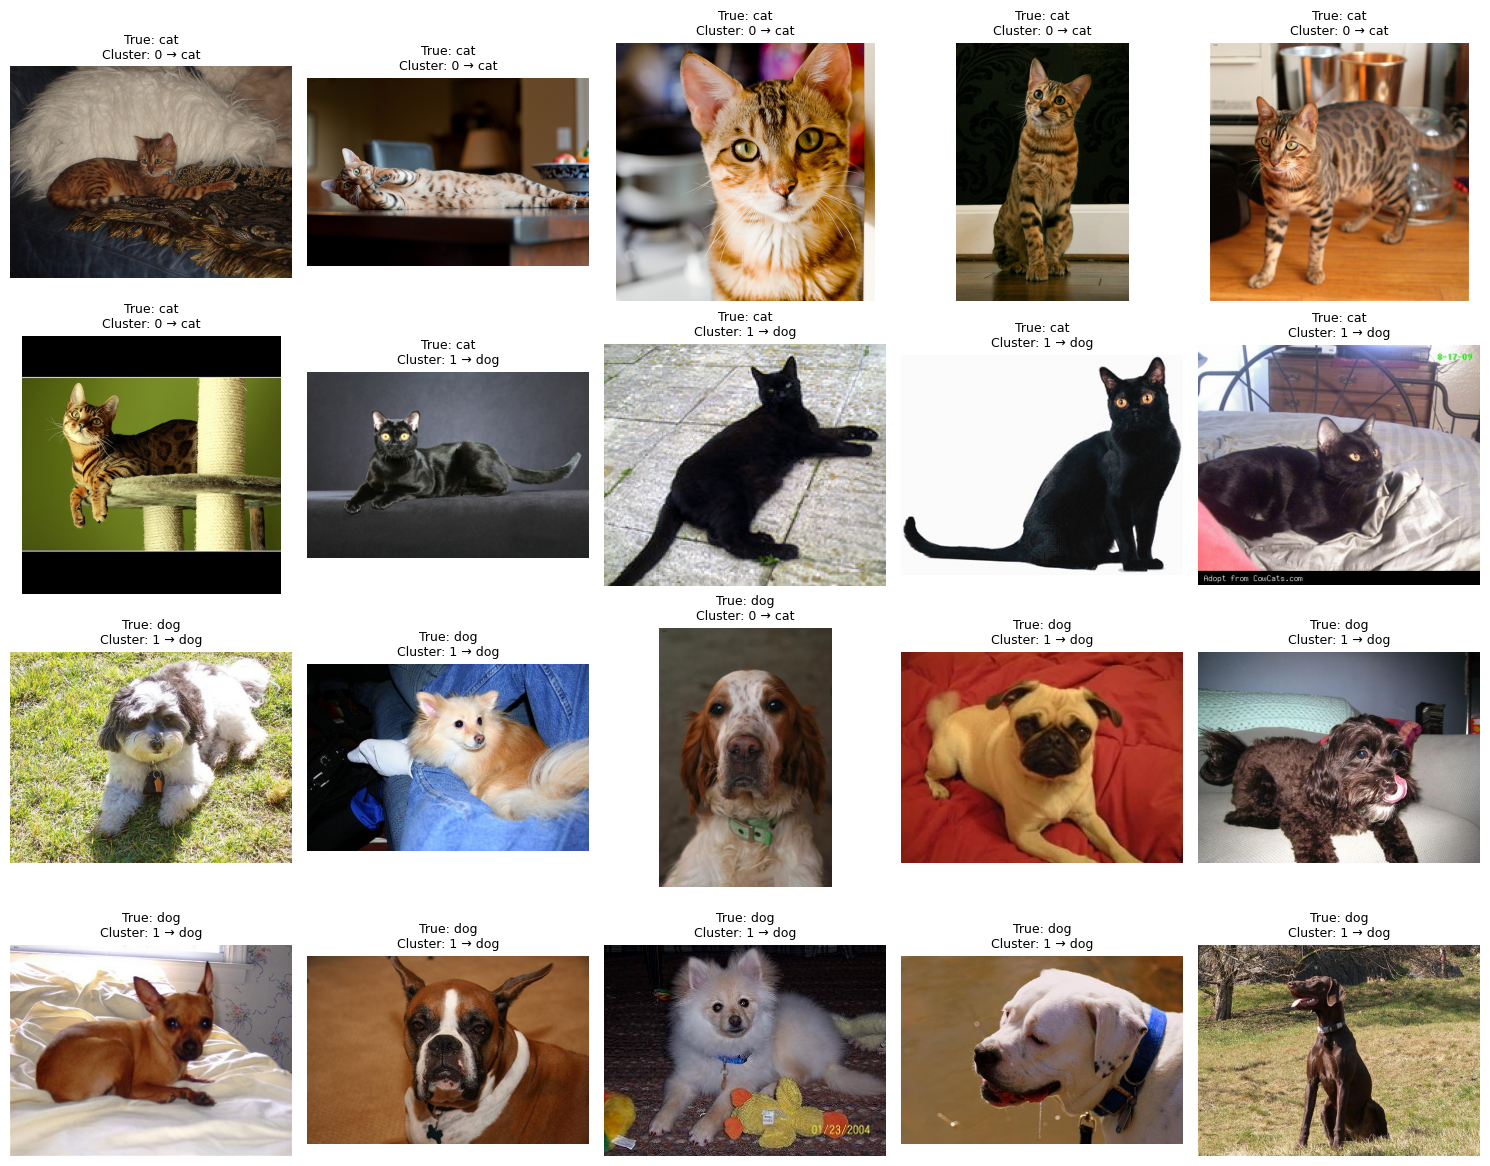

In [41]:
cols = 5
rows = int(np.ceil(len(valid_paths) / cols))
plt.figure(figsize=(15, 3 * rows))

for i, path in enumerate(valid_paths):
    img = Image.open(path).convert("RGB")
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.axis("off")
    title = f"True: {results_df.loc[i, 'true_label']}\nCluster: {results_df.loc[i, 'cluster']} → {results_df.loc[i, 'predicted_label']}"
    plt.title(title, fontsize=9)

plt.tight_layout()
plt.show()

### Exercise 2: Image Classification with DINOv2

In this exercise you'll use a DINOv2 model with a pre-trained linear head to classify an image. You will observe how the model maps visual features to specific ImageNet-1k categories.

Instructions:
1. For this exercise, you must use the following Model ID. This specific checkpoint includes the necessary classification head trained on ImageNet-1k:

    Model ID: `facebook/dinov2-small-imagenet1k-1-layer`

2. Find an image online to make the inference. To ensure the model has a fair chance of success, the image should belong to one of the ImageNet-1k classes (e.g., a Golden Retriever, a grand piano, a school bus, or a coffee mug).

In [42]:
model_name = "facebook/dinov2-small-imagenet1k-1-layer"

processor = AutoImageProcessor.from_pretrained(model_name)
classifier_model = AutoModelForImageClassification.from_pretrained(model_name)

device = "cuda" if torch.cuda.is_available() else "cpu"
classifier_model = classifier_model.to(device)
classifier_model.eval()

print("Model loaded successfully on:", device)

Loading weights:   0%|          | 0/225 [00:00<?, ?it/s]

Model loaded successfully on: cpu


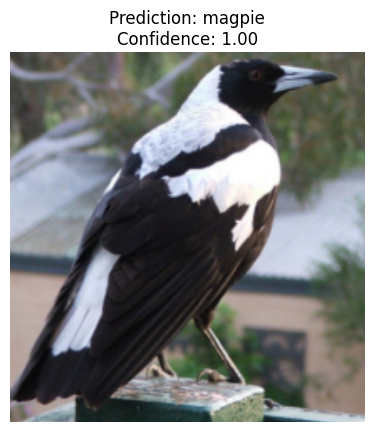

Image path: /content/imgnet.png
Predicted ImageNet label: magpie
Confidence: 0.9990383386611938


In [43]:
test_image_path = "/content/imgnet.png"

image = Image.open(test_image_path).convert("RGB")

inputs = processor(images=image, return_tensors="pt").to(device)

with torch.no_grad():
    outputs = classifier_model(**inputs)
    logits = outputs.logits
    probs = torch.softmax(logits, dim=1)

predicted_class_id = probs.argmax(dim=1).item()
predicted_label = classifier_model.config.id2label[predicted_class_id]
confidence = probs[0, predicted_class_id].item()

plt.imshow(image)
plt.axis("off")
plt.title(f"Prediction: {predicted_label}\nConfidence: {confidence:.2f}")
plt.show()

print("Image path:", test_image_path)
print("Predicted ImageNet label:", predicted_label)
print("Confidence:", confidence)

In [44]:
top5_probs, top5_ids = torch.topk(probs, k=5)

print("Top-5 predictions:")

for i in range(5):
    class_id = top5_ids[0][i].item()
    label = classifier_model.config.id2label[class_id]
    score = top5_probs[0][i].item()
    print(f"{i+1}. {label} - {score:.4f}")

Top-5 predictions:
1. magpie - 0.9990
2. water ouzel, dipper - 0.0003
3. black grouse - 0.0003
4. jay - 0.0001
5. hair slide - 0.0000


In [45]:
top5_data = []

for i in range(5):
    class_id = top5_ids[0][i].item()
    label = classifier_model.config.id2label[class_id]
    score = top5_probs[0][i].item()

    top5_data.append({
        "rank": i + 1,
        "predicted_label": label,
        "confidence": score
    })

top5_df = pd.DataFrame(top5_data)
top5_df

,rank,predicted_label,confidence
0,1,magpie,0.999038
1,2,"water ouzel, dipper",0.000318
2,3,black grouse,0.000287
3,4,jay,0.000063
4,5,hair slide,0.000023
